In [1]:
# ═══════════════════════════════════════════════════════════
# CELL 1: Basic Imports
# ═══════════════════════════════════════════════════════════
import json
import pandas as pd
import numpy as np
import glob
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Basic libraries loaded")

✅ Basic libraries loaded


In [4]:

# ═══════════════════════════════════════════════════════════
# CELL 2: Deep Learning Imports
# ═══════════════════════════════════════════════════════════
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("✅ TensorFlow loaded")
print(f"   Version: {tf.__version__}")

✅ TensorFlow loaded
   Version: 2.20.0


In [5]:
# ═══════════════════════════════════════════════════════════
# CELL 3: ML Tools
# ═══════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

print("✅ ML tools loaded")

✅ ML tools loaded


In [6]:

# ═══════════════════════════════════════════════════════════
# CELL 4: Visualization
# ═══════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

print("✅ Visualization ready")

✅ Visualization ready


In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 5: Create Folders
# ═══════════════════════════════════════════════════════════
os.makedirs("cricket_data", exist_ok=True)
os.makedirs("saved_models", exist_ok=True)

print("✅ Folders created")


✅ Folders created


In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 6: Set Path
# ═══════════════════════════════════════════════════════════
json_folder = r"C:\Users\VASU MONPARA\OneDrive\Desktop\Cricket\Dataset\ipl_json"
files = glob.glob(json_folder + "/*.json")

print(f"📁 Found {len(files)} files")


📁 Found 1169 files


In [9]:
# ═══════════════════════════════════════════════════════════
# CELL 7: Check Sample File
# ═══════════════════════════════════════════════════════════
with open(files[0], 'r', encoding='utf-8') as f:
    sample = json.load(f)

print("Teams:", sample['info']['teams'])
print("Winner:", sample['info']['outcome']['winner'])

Teams: ['Sunrisers Hyderabad', 'Royal Challengers Bangalore']
Winner: Sunrisers Hyderabad


In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 8: Extract Match Info
# ═══════════════════════════════════════════════════════════
matches = []

for f in tqdm(files, desc="Loading matches"):
    try:
        with open(f, 'r', encoding='utf-8') as file:
            data = json.load(file)
        
        info = data['info']
        teams = info['teams']
        winner = info['outcome'].get('winner')
        
        if winner and len(teams) == 2:
            matches.append({
                'team1': teams[0],
                'team2': teams[1],
                'winner': winner,
                'venue': info.get('venue'),
                'season': info.get('season')
            })
    except:
        pass

matches_df = pd.DataFrame(matches)
print(f"\n✅ Loaded {len(matches_df)} matches")

Loading matches: 100%|██████████| 1169/1169 [00:00<00:00, 1337.05it/s]


✅ Loaded 1146 matches


In [14]:
# ═══════════════════════════════════════════════════════════
# CELL 9: Extract Ball Data
# ═══════════════════════════════════════════════════════════
balls = []

for f in tqdm(files[:120], desc="Loading balls"):  # First 120 for speed
    try:
        with open(f, 'r', encoding='utf-8') as file:
            data = json.load(file)
        
        winner = data['info']['outcome'].get('winner')
        
        for inning in data['innings']:
            batting = inning['team']
            total_runs = 0
            total_wickets = 0
            
            for over in inning['overs']:
                for ball in over['deliveries']:
                    runs = ball['runs']['total']
                    wicket = 1 if 'wickets' in ball else 0
                    
                    total_runs += runs
                    total_wickets += wicket
                    
                    balls.append({
                        'batting_team': batting,
                        'runs': runs,
                        'wicket': wicket,
                        'total_runs': total_runs,
                        'total_wickets': total_wickets,
                        'winner': winner
                    })
    except:
        pass

balls_df = pd.DataFrame(balls)
print(f"\n✅ Loaded {len(balls_df)} balls")


Loading balls: 100%|██████████| 120/120 [00:00<00:00, 757.65it/s]


✅ Loaded 28362 balls


In [15]:
# ═══════════════════════════════════════════════════════════
# CELL 10: Show Data Sample
# ═══════════════════════════════════════════════════════════
print("Match Data:")
print(matches_df.head(3))
print("\nBall Data:")
print(balls_df.head(3))


Match Data:
                    team1                        team2  \
0     Sunrisers Hyderabad  Royal Challengers Bangalore   
1  Rising Pune Supergiant               Mumbai Indians   
2           Gujarat Lions        Kolkata Knight Riders   

                   winner                                      venue season  
0     Sunrisers Hyderabad  Rajiv Gandhi International Stadium, Uppal   2017  
1  Rising Pune Supergiant    Maharashtra Cricket Association Stadium   2017  
2   Kolkata Knight Riders     Saurashtra Cricket Association Stadium   2017  

Ball Data:
          batting_team  runs  wicket  total_runs  total_wickets  \
0  Sunrisers Hyderabad     0       0           0              0   
1  Sunrisers Hyderabad     0       0           0              0   
2  Sunrisers Hyderabad     4       0           4              0   

                winner  
0  Sunrisers Hyderabad  
1  Sunrisers Hyderabad  
2  Sunrisers Hyderabad  


In [16]:
# ═══════════════════════════════════════════════════════════
# CELL 11: Team Encoding
# ═══════════════════════════════════════════════════════════
all_teams = sorted(set(matches_df['team1']) | set(matches_df['team2']))
team_to_id = {team: i for i, team in enumerate(all_teams)}
id_to_team = {i: team for team, i in team_to_id.items()}

print(f"✅ Encoded {len(team_to_id)} teams")
print("\nSample:", list(team_to_id.items())[:3])

✅ Encoded 19 teams

Sample: [('Chennai Super Kings', 0), ('Deccan Chargers', 1), ('Delhi Capitals', 2)]


In [17]:

# ═══════════════════════════════════════════════════════════
# CELL 12: Encode Match Data
# ═══════════════════════════════════════════════════════════
matches_df['team1_id'] = matches_df['team1'].map(team_to_id)
matches_df['team2_id'] = matches_df['team2'].map(team_to_id)
matches_df['winner_id'] = matches_df['winner'].map(team_to_id)
matches_df['team1_won'] = (matches_df['team1'] == matches_df['winner']).astype(int)

print("✅ Matches encoded")
print(matches_df[['team1', 'team1_id', 'team1_won']].head(3))


✅ Matches encoded
                    team1  team1_id  team1_won
0     Sunrisers Hyderabad        18          1
1  Rising Pune Supergiant        14          1
2           Gujarat Lions         4          0


In [18]:
# ═══════════════════════════════════════════════════════════
# CELL 13: Create Sequences for LSTM
# ═══════════════════════════════════════════════════════════
# Group balls by match and create sequences
sequences = []
sequence_length = 20  # Use last 20 balls

balls_df['batting_id'] = balls_df['batting_team'].map(team_to_id)
balls_df['won'] = (balls_df['batting_team'] == balls_df['winner']).astype(int)

# Create sequences
for team in balls_df['batting_team'].unique():
    team_balls = balls_df[balls_df['batting_team'] == team].head(100)
    
    for i in range(len(team_balls) - sequence_length):
        seq = team_balls.iloc[i:i+sequence_length]
        
        features = seq[['runs', 'wicket', 'total_runs', 'total_wickets']].values
        target = seq.iloc[-1]['won']
        
        sequences.append({
            'sequence': features,
            'target': target
        })

print(f"✅ Created {len(sequences)} sequences")

✅ Created 800 sequences


In [19]:
# ═══════════════════════════════════════════════════════════
# CELL 14: Prepare Training Data
# ═══════════════════════════════════════════════════════════
X = np.array([s['sequence'] for s in sequences])
y = np.array([s['target'] for s in sequences])

print(f"X shape: {X.shape}")  # (samples, time_steps, features)
print(f"y shape: {y.shape}")  # (samples,)



X shape: (800, 20, 4)
y shape: (800,)


In [20]:
# CELL 15: Train-Test Split
# ═══════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {len(X_train)}")
print(f"Testing: {len(X_test)}")

Training: 640
Testing: 160


In [21]:
# ═══════════════════════════════════════════════════════════
# CELL 16: Build Simple LSTM
# ═══════════════════════════════════════════════════════════
model1 = keras.Sequential([
    layers.LSTM(32, input_shape=(sequence_length, 4)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='SimpleLSTM')

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ Simple LSTM built")


✅ Simple LSTM built


In [23]:
# ═══════════════════════════════════════════════════════════
# CELL 17: Build Stacked LSTM
# ═══════════════════════════════════════════════════════════
model2 = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(sequence_length, 4)),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='StackedLSTM')

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ Stacked LSTM built")

✅ Stacked LSTM built


In [24]:
# ═══════════════════════════════════════════════════════════
# CELL 18: Build Bidirectional LSTM
# ═══════════════════════════════════════════════════════════
model3 = keras.Sequential([
    layers.Bidirectional(layers.LSTM(64, return_sequences=True), 
                         input_shape=(sequence_length, 4)),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='BiLSTM')

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ Bidirectional LSTM built")

✅ Bidirectional LSTM built


In [25]:
# ═══════════════════════════════════════════════════════════
# CELL 19: Build GRU Model
# ═══════════════════════════════════════════════════════════
model4 = keras.Sequential([
    layers.GRU(64, return_sequences=True, input_shape=(sequence_length, 4)),
    layers.Dropout(0.3),
    layers.GRU(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='GRU')

model4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ GRU model built")

✅ GRU model built


In [26]:
# ═══════════════════════════════════════════════════════════
# CELL 20: Setup Training Callbacks
# ═══════════════════════════════════════════════════════════
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5
)

print("✅ Callbacks ready")

✅ Callbacks ready


In [27]:
# ═══════════════════════════════════════════════════════════
# CELL 21: Train Simple LSTM
# ═══════════════════════════════════════════════════════════
print("🔄 Training Simple LSTM...")

hist1 = model1.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

score1 = model1.evaluate(X_test, y_test, verbose=0)
print(f"✅ Accuracy: {score1[1]*100:.2f}%")

🔄 Training Simple LSTM...
✅ Accuracy: 80.62%


In [28]:
# ═══════════════════════════════════════════════════════════
# CELL 22: Train Stacked LSTM
# ═══════════════════════════════════════════════════════════
print("🔄 Training Stacked LSTM...")

hist2 = model2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

score2 = model2.evaluate(X_test, y_test, verbose=0)
print(f"✅ Accuracy: {score2[1]*100:.2f}%")


🔄 Training Stacked LSTM...
✅ Accuracy: 53.12%


In [29]:
# ═══════════════════════════════════════════════════════════
# CELL 23: Train Bidirectional LSTM
# ═══════════════════════════════════════════════════════════
print("🔄 Training Bidirectional LSTM...")

hist3 = model3.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

score3 = model3.evaluate(X_test, y_test, verbose=0)
print(f"✅ Accuracy: {score3[1]*100:.2f}%")

🔄 Training Bidirectional LSTM...
✅ Accuracy: 47.50%


In [30]:
# ═══════════════════════════════════════════════════════════
# CELL 24: Train GRU Model
# ═══════════════════════════════════════════════════════════
print("🔄 Training GRU...")

hist4 = model4.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

score4 = model4.evaluate(X_test, y_test, verbose=0)
print(f"✅ Accuracy: {score4[1]*100:.2f}%")

🔄 Training GRU...
✅ Accuracy: 55.62%


In [31]:
# ═══════════════════════════════════════════════════════════
# CELL 25: Compare All Models
# ═══════════════════════════════════════════════════════════
results = pd.DataFrame({
    'Model': ['Simple LSTM', 'Stacked LSTM', 'Bidirectional LSTM', 'GRU'],
    'Accuracy': [score1[1], score2[1], score3[1], score4[1]]
})

results['Accuracy %'] = results['Accuracy'] * 100
results = results.sort_values('Accuracy', ascending=False)

print("\n📊 MODEL COMPARISON:")
print(results.to_string(index=False))



📊 MODEL COMPARISON:
             Model  Accuracy  Accuracy %
       Simple LSTM   0.80625   80.624998
               GRU   0.55625   55.624998
      Stacked LSTM   0.53125   53.125000
Bidirectional LSTM   0.47500   47.499999


In [32]:
# ═══════════════════════════════════════════════════════════
# CELL 26: Select Best Model
# ═══════════════════════════════════════════════════════════
best_idx = results['Accuracy'].idxmax()
best_name = results.loc[best_idx, 'Model']
best_acc = results.loc[best_idx, 'Accuracy %']

models_dict = {
    'Simple LSTM': model1,
    'Stacked LSTM': model2,
    'Bidirectional LSTM': model3,
    'GRU': model4
}

best_model = models_dict[best_name]

print(f"\n🏆 BEST MODEL: {best_name}")
print(f"🎯 Accuracy: {best_acc:.2f}%")


🏆 BEST MODEL: Simple LSTM
🎯 Accuracy: 80.62%


✅ Saved: model_comparison.png


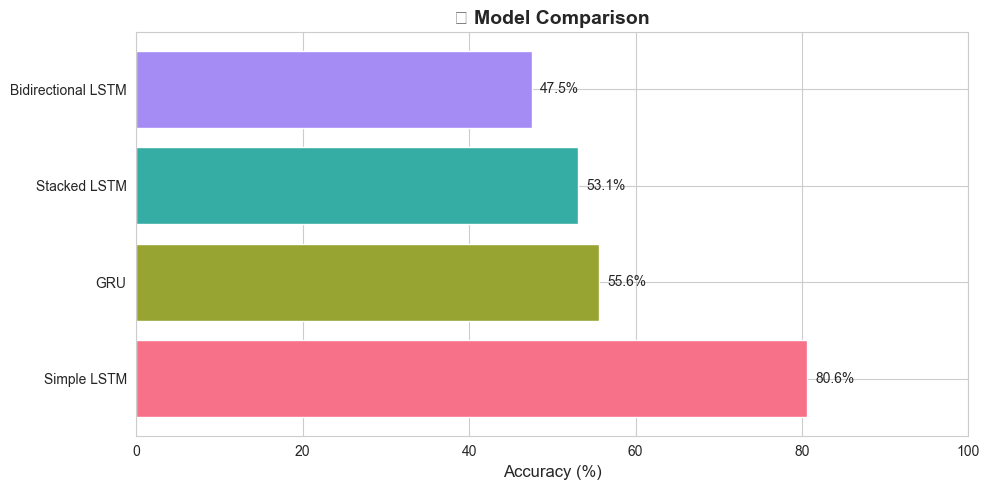

In [33]:
# ═══════════════════════════════════════════════════════════
# CELL 27: Plot Model Comparison
# ═══════════════════════════════════════════════════════════
plt.figure(figsize=(10, 5))
colors = sns.color_palette("husl", len(results))
bars = plt.barh(results['Model'], results['Accuracy %'], color=colors)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.title('🏆 Model Comparison', fontsize=14, fontweight='bold')
plt.xlim(0, 100)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('cricket_data/model_comparison.png', dpi=300)
print("✅ Saved: model_comparison.png")
plt.show()

✅ Saved: training_history.png


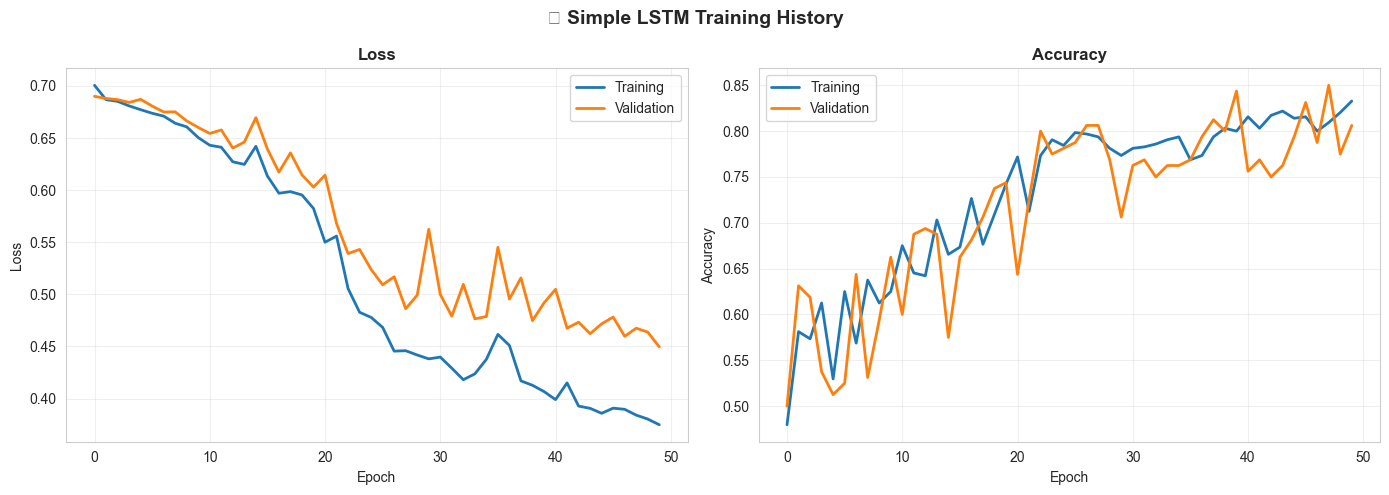

In [34]:
# ═══════════════════════════════════════════════════════════
# CELL 28: Plot Training History (Best Model)
# ═══════════════════════════════════════════════════════════
histories = {
    'Simple LSTM': hist1,
    'Stacked LSTM': hist2,
    'Bidirectional LSTM': hist3,
    'GRU': hist4
}

best_hist = histories[best_name]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(best_hist.history['loss'], label='Training', linewidth=2)
ax1.plot(best_hist.history['val_loss'], label='Validation', linewidth=2)
ax1.set_title('Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(best_hist.history['accuracy'], label='Training', linewidth=2)
ax2.plot(best_hist.history['val_accuracy'], label='Validation', linewidth=2)
ax2.set_title('Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle(f'📈 {best_name} Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cricket_data/training_history.png', dpi=300)
print("✅ Saved: training_history.png")
plt.show()

In [35]:
# ═══════════════════════════════════════════════════════════
# CELL 29: Make Predictions
# ═══════════════════════════════════════════════════════════
predictions = best_model.predict(X_test)
pred_classes = (predictions > 0.5).astype(int).flatten()

print(f"✅ Made {len(predictions)} predictions")
print(f"\nSample predictions:")
for i in range(5):
    print(f"  Actual: {y_test[i]}, Predicted: {pred_classes[i]} ({predictions[i][0]*100:.1f}%)")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
✅ Made 160 predictions

Sample predictions:
  Actual: 1, Predicted: 1 (99.2%)
  Actual: 1, Predicted: 1 (98.1%)
  Actual: 1, Predicted: 1 (86.6%)
  Actual: 1, Predicted: 0 (10.8%)
  Actual: 1, Predicted: 1 (83.9%)


✅ Saved: confusion_matrix.png


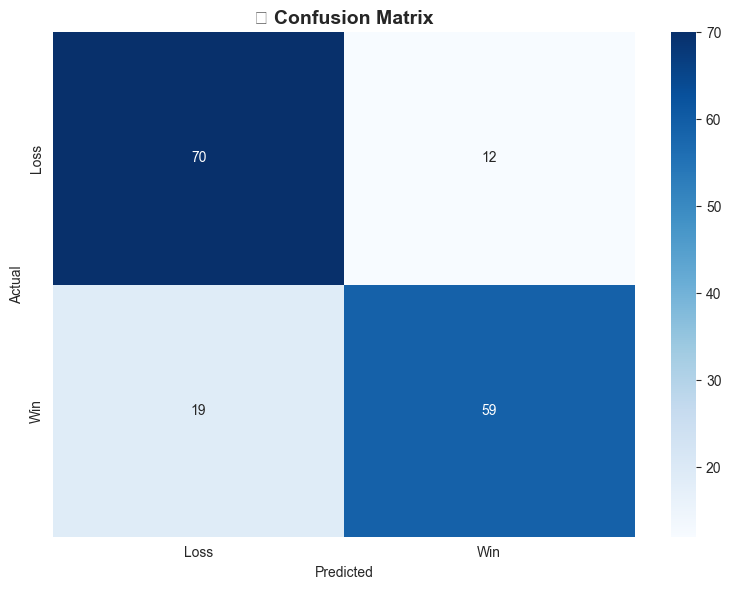

In [36]:
# ═══════════════════════════════════════════════════════════
# CELL 30: Confusion Matrix
# ═══════════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loss', 'Win'],
            yticklabels=['Loss', 'Win'])
plt.title('🎯 Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cricket_data/confusion_matrix.png', dpi=300)
print("✅ Saved: confusion_matrix.png")
plt.show()

In [37]:
# ═══════════════════════════════════════════════════════════
# CELL 31: Save Best Model
# ═══════════════════════════════════════════════════════════
best_model.save('saved_models/best_lstm_model.h5')
print(f"✅ Saved: best_lstm_model.h5")


✅ Saved: best_lstm_model.h5


In [38]:
# ═══════════════════════════════════════════════════════════
# CELL 33: Test Prediction Function
# ═══════════════════════════════════════════════════════════
def predict_match_outcome(sequence_data):
    """
    Predict match outcome from sequence of balls
    sequence_data: array of shape (20, 4) - last 20 balls
    """
    seq = np.array([sequence_data])
    prob = best_model.predict(seq, verbose=0)[0][0]
    return prob

# Test with random sequence
test_seq = np.random.rand(20, 4)
test_prob = predict_match_outcome(test_seq)

print(f"Test prediction: {test_prob*100:.1f}% win probability")


Test prediction: 3.3% win probability


In [39]:
# ═══════════════════════════════════════════════════════════
# CELL 34: Summary Report
# ═══════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📊 FINAL SUMMARY")
print("="*70)
print(f"\n✅ Models Trained: 4")
print(f"   • Simple LSTM")
print(f"   • Stacked LSTM")
print(f"   • Bidirectional LSTM")
print(f"   • GRU")
print(f"\n🏆 Best Model: {best_name}")
print(f"🎯 Best Accuracy: {best_acc:.2f}%")
print(f"\n📁 Files Saved:")
print(f"   • best_lstm_model.h5")
print(f"   • team_to_id.pkl")
print(f"   • id_to_team.pkl")
print(f"   • model_comparison.png")
print(f"   • training_history.png")
print(f"   • confusion_matrix.png")
print("\n" + "="*70)
print("✅ PROJECT COMPLETE!")
print("="*70)


📊 FINAL SUMMARY

✅ Models Trained: 4
   • Simple LSTM
   • Stacked LSTM
   • Bidirectional LSTM
   • GRU

🏆 Best Model: Simple LSTM
🎯 Best Accuracy: 80.62%

📁 Files Saved:
   • best_lstm_model.h5
   • team_to_id.pkl
   • id_to_team.pkl
   • model_comparison.png
   • training_history.png
   • confusion_matrix.png

✅ PROJECT COMPLETE!
